# Una IA diseñó un envase para ARN que ningún virus inventó

Meter material genético dentro de una célula ajena es lo único que los virus llevan miles de millones de años haciendo. Y casi todos, por caminos evolutivos separados, terminaron en la misma forma de cápsula. La pregunta que se hizo este equipo es incómoda: ¿esa forma es la mejor posible, o es solo hasta donde alcanzó a llegar la evolución?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Schuhmacher et al. (2026) — *Creating bottom-up RNA transfer vehicles from synthetic protein assemblies*
**Revista:** Nature · [DOI: 10.1038/s41586-026-10952-3](https://doi.org/10.1038/s41586-026-10952-3)
**Datos:** Source Data del propio artículo (acceso abierto)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-02-vehiculos-arn-proteinas-ia/notebook.ipynb)

📺 **Video:** [Pendiente]

## Qué hicieron

El equipo partió de andamios de proteína dibujados por modelos generativos de inteligencia artificial: jaulas huecas con tamaños y simetrías que no existen en la naturaleza. A cada jaula le colgaron dos piezas prestadas de la biología real — un dominio que agarra ARN y otro que hace brotar una vesícula desde la célula —, y las pusieron a competir.

El cribado mide **tres pasos encadenados**, cada uno con su propio sensor de luz:

1. **Liberación** — cuánto vehículo logra salir de la célula que lo fabrica.
2. **Captación** — cuánto de eso llega al interior de una célula diana.
3. **Entrega** — cuánto del ARN que iba dentro termina realmente funcionando.

Son 39 jaulas más un control sin jaula (`no cage`), con 6 réplicas biológicas cada una — salvo siete constructos a los que se les perdió un pocillo en alguno de los paneles y quedan con 5. Todas las señales van en relación a **HE0902**, la jaula de 20 caras (icosaédrica): la forma a la que converge casi cualquier envoltura viral —la cápside—. Ese es el rival de casa.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
GANADOR   = 'HE0690'   # el mejor diseño del cribado (el paper lo llama STV-C8)
CAPSIDE   = 'HE0902'   # andamio icosaédrico: la forma a la que converge casi todo virus
CONTROL   = 'no cage'  # vesículas sin ningún andamio de proteína

FUENTE = ('Fuente: Schuhmacher et al. (2026), Nature | '
          'Datos: Source Data del mismo artículo')

COLOR_DATOS      = '#2563EB'
COLOR_ALERTA     = '#DC2626'
COLOR_SECUNDARIO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_CONTEXTO   = '#BBBBBB'

import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── Estilo editorial CaM ───────────────────────────────────────────
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Descarga automática (para Colab) ───────────────────────────────
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-09-02-vehiculos-arn-proteinas-ia'
ARCHIVOS = ['screening_liberacion.csv', 'screening_captacion.csv',
            'screening_entrega.csv', 'dosis_por_mfi.csv',
            'curva_dosis_egfp.csv', 'benchmark_vehiculos.csv',
            'reprogramacion_ascl1.csv', 'rnabp_liberacion_arn.csv',
            'estabilidad_sangre.csv']
DATOS = 'datos' if os.path.isdir('datos') else '/home/jupyter/datos'
os.makedirs(DATOS, exist_ok=True)
for archivo in ARCHIVOS:
    destino = f'{DATOS}/{archivo}'
    if not os.path.exists(destino):
        urllib.request.urlretrieve(f'{BASE}/datos/{archivo}', destino)


def es(x, dec=2):
    """Formato español: punto para los miles, coma para los decimales."""
    return f'{x:,.{dec}f}'.replace(',', 'X').replace('.', ',').replace('X', '.')


def d_de_cohen(a, b):
    """d de Cohen para dos grupos independientes (desviación combinada)."""
    na, nb = len(a), len(b)
    s = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb - 1) * b.std(ddof=1) ** 2)
                / (na + nb - 2))
    return (a.mean() - b.mean()) / s


# ── Carga ──────────────────────────────────────────────────────────
liberacion  = pd.read_csv(f'{DATOS}/screening_liberacion.csv')
captacion   = pd.read_csv(f'{DATOS}/screening_captacion.csv')
entrega     = pd.read_csv(f'{DATOS}/screening_entrega.csv')
dosis_mfi   = pd.read_csv(f'{DATOS}/dosis_por_mfi.csv')
curva       = pd.read_csv(f'{DATOS}/curva_dosis_egfp.csv')
benchmark   = pd.read_csv(f'{DATOS}/benchmark_vehiculos.csv')

# Los tres paneles traen los constructos en ORDEN DISTINTO: se cruzan por
# nombre, nunca por posición.
cribado = pd.DataFrame({
    'liberacion': liberacion.groupby('construct').senal.mean(),
    'captacion':  captacion.groupby('construct').senal.mean(),
    'entrega':    entrega.groupby('construct').senal.mean(),
})
jaulas = cribado.drop(CONTROL)   # los 39 diseños, sin el control

print(f'Cribado: {len(jaulas)} jaulas + control «{CONTROL}»')
print(f'Réplicas por constructo: {sorted(int(v) for v in entrega.groupby("construct").size().unique())}')
print()
print(f'Entrega — mediana {es(jaulas.entrega.median())} · '
      f'mínimo {es(jaulas.entrega.min())} ({jaulas.entrega.idxmin()}) · '
      f'máximo {es(jaulas.entrega.max())} ({jaulas.entrega.idxmax()})')
print(f'Control «{CONTROL}»: {es(cribado.entrega[CONTROL])} · '
      f'{CAPSIDE} (icosaédrico): {es(cribado.entrega[CAPSIDE])} por definición')
print()
print(f'Jaulas que superan al icosaédrico en entrega: '
      f'{(jaulas.entrega > jaulas.entrega[CAPSIDE]).sum()}/{len(jaulas)}')
print(f'Jaulas que superan al control sin jaula:     '
      f'{(jaulas.entrega > cribado.entrega[CONTROL]).sum()}/{len(jaulas)}')

Cribado: 39 jaulas + control «no cage»
Réplicas por constructo: [5, 6]

Entrega — mediana 1,49 · mínimo 0,07 (HE0482) · máximo 10,77 (HE0690)
Control «no cage»: 0,42 · HE0902 (icosaédrico): 1,00 por definición

Jaulas que superan al icosaédrico en entrega: 27/39
Jaulas que superan al control sin jaula:     36/39


## Empecemos por el final

De esas 39 jaulas salió una ganadora, la que el paper bautiza **STV-C8**. Y en vez de compararla contra otro diseño de laboratorio, la midieron contra uno de los envases de ARN más usados hoy: la nanopartícula lipídica, la misma familia de grasa que transporta el ARN de las vacunas.

Misma dosis creciente de ARN, mismas células, y se cuenta cuántas se encienden.

Aquí está.

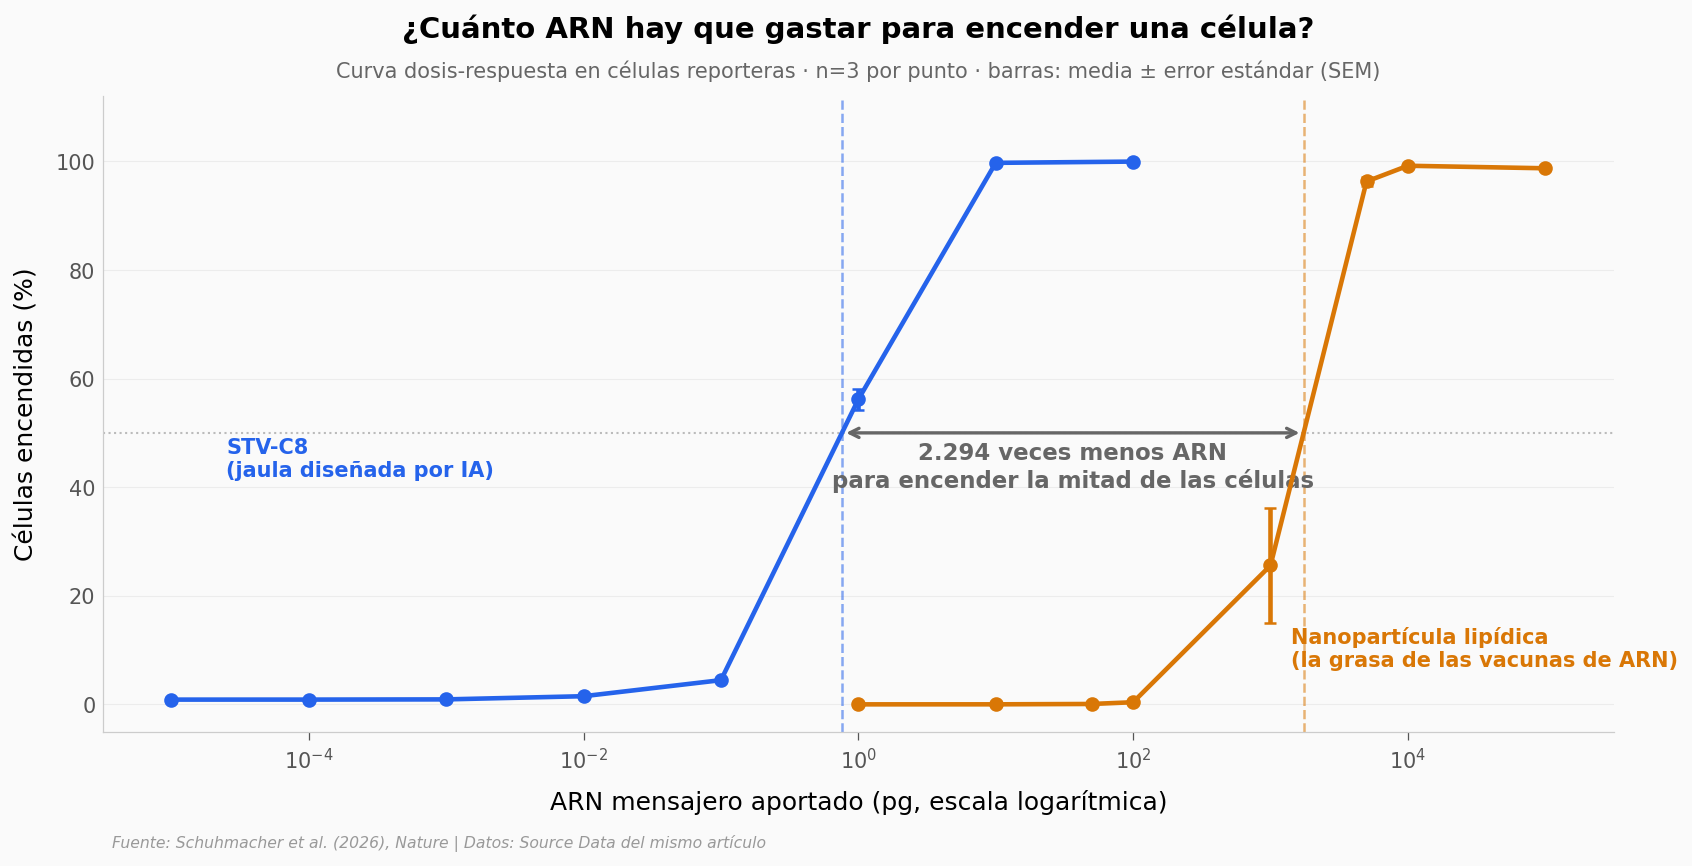

Dosis para el 50 % de células encendidas:
  STV-C8: 0,76 pg
  Nanopartícula lipídica: 1.743 pg
  Desplazamiento: 2.294 veces


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))


def dosis_media_eficaz(vehiculo):
    """Dosis a la que se enciende la mitad de las células, interpolada en log10."""
    g = (curva[curva.vehiculo == vehiculo]
         .groupby('pg_arn').pct_celulas_egfp_pos.mean().sort_index())
    # np.interp exige que el eje de interpolación crezca: la curva de la
    # nanopartícula baja levemente tras saturar, así que se corta en su máximo.
    g = g.iloc[:g.values.argmax() + 1]
    return 10 ** np.interp(50, g.values, np.log10(g.index.values))


DE50 = {v: dosis_media_eficaz(v) for v in ['STV-C8', 'LNP']}
RAZON_DE50 = DE50['LNP'] / DE50['STV-C8']

for vehiculo, color in [('LNP', COLOR_REFERENCIA), ('STV-C8', COLOR_DATOS)]:
    g = curva[curva.vehiculo == vehiculo].groupby('pg_arn').pct_celulas_egfp_pos
    medias, desv, n = g.mean(), g.std(ddof=1), g.size()
    ax.errorbar(medias.index, medias.values, yerr=(desv / np.sqrt(n)).values,
                color=color, marker='o', markersize=6, linewidth=2.2,
                capsize=3, capthick=1.2, zorder=5)
    ax.axvline(DE50[vehiculo], color=color, linewidth=1.2,
               linestyle='--', alpha=0.55, zorder=2)

ax.axhline(50, color=COLOR_CONTEXTO, linewidth=1, linestyle=':', zorder=1)
ax.annotate('', xy=(DE50['LNP'], 50), xytext=(DE50['STV-C8'], 50),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.6), zorder=6)
ax.text(np.sqrt(DE50['LNP'] * DE50['STV-C8']), 40,
        f'{es(RAZON_DE50, 0)} veces menos ARN\npara encender la mitad de las células',
        ha='center', fontsize=11, fontweight='bold', color='#666666')

ax.text(2.5e-5, 42, 'STV-C8\n(jaula diseñada por IA)', fontsize=10,
        color=COLOR_DATOS, fontweight='bold', ha='left')
ax.text(1.4e3, 7, 'Nanopartícula lipídica\n(la grasa de las vacunas de ARN)',
        fontsize=10, color=COLOR_REFERENCIA, fontweight='bold', ha='left')

ax.set_xscale('log')
ax.set_xlabel('ARN mensajero aportado (pg, escala logarítmica)')
ax.set_ylabel('Células encendidas (%)')
ax.set_ylim(-5, 112)
ax.set_title('¿Cuánto ARN hay que gastar para encender una célula?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Curva dosis-respuesta en células reporteras · n=3 por punto · '
                   'barras: media ± error estándar (SEM)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/curva_dosis.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Dosis para el 50 % de células encendidas:')
print(f'  STV-C8: {es(DE50["STV-C8"], 2)} pg')
print(f'  Nanopartícula lipídica: {es(DE50["LNP"], 0)} pg')
print(f'  Desplazamiento: {es(RAZON_DE50, 0)} veces')

### Lo que dice ese hueco

El eje horizontal es logarítmico, así que la distancia entre las dos curvas engaña a la vista: no es «el doble» ni «diez veces». Para llevar a la mitad de las células al mismo punto, la nanopartícula lipídica necesita unas **2.294 veces** más ARN que la jaula de IA. Tres órdenes de magnitud largos.

Y hay un detalle que se ve mejor mirando dónde empieza cada curva: la nanopartícula todavía no mueve nada con 100 pg de ARN, una dosis con la que STV-C8 ya saturó el cultivo. No es que una sea más rápida — es que trabajan en rangos de dosis que casi no se tocan.

Dos frenos antes de emocionarse: son **n=3 réplicas por punto**, y esto ocurre en células de cultivo, no en un organismo.

## ¿Y si contamos el ARN en vez de la dosis?

La curva compara lo que uno *le da* al vehículo. Pero parte de ese ARN nunca entra al vehículo — se queda en el tubo. El equipo hizo la cuenta fina: contó molécula a molécula (RT-qPCR) cuánto ARN lleva de verdad cada preparación, y calculó cuántos picogramos hacen falta para producir **una unidad de señal fluorescente**.

Esa es la cifra del titular. Menos es mejor.

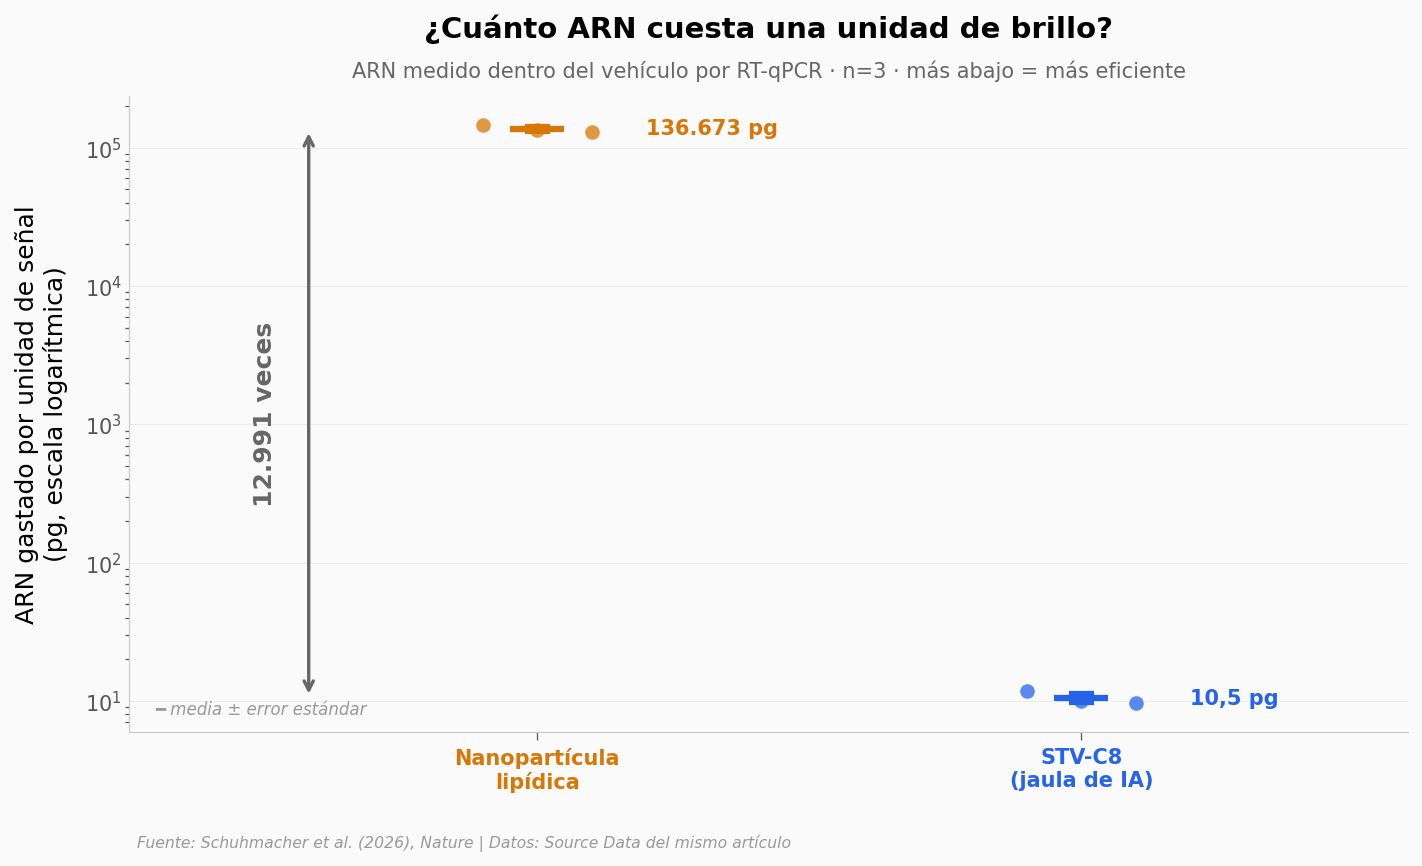

Razón de medias: 12.991 veces (n=3 vs 3)
d de Cohen: 24,0  |  Mann-Whitney p = 0,100
Ojo con ese p: con 3 contra 3, 0,1 es el valor más bajo que el test puede dar.
No es «no hay diferencia» — es que el test no tiene resolución. Lo que pesa aquí
es la magnitud, no el contraste.


In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))

np.random.seed(42)
grupos = [('LNP', 'Nanopartícula\nlipídica', COLOR_REFERENCIA),
          ('STV-C8', 'STV-C8\n(jaula de IA)', COLOR_DATOS)]
posiciones = [0, 1]

for pos, (clave, etiqueta, color) in zip(posiciones, grupos):
    vals = dosis_mfi[dosis_mfi.vehiculo == clave].pg_arn_por_unidad_mfi.values
    x_strip = np.linspace(pos - 0.10, pos + 0.10, len(vals))
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=55, alpha=0.75,
               edgecolors='white', linewidths=0.5, zorder=5)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(len(vals))
    ax.errorbar(pos, media, yerr=sem, fmt='_', color=color, markersize=26,
                markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
    ax.text(pos + 0.20, media, f'{es(media, 0 if media >= 1000 else 1)} pg', fontsize=10,
            color=color, fontweight='bold', va='center')

vals_lnp = dosis_mfi[dosis_mfi.vehiculo == 'LNP'].pg_arn_por_unidad_mfi.values
vals_stv = dosis_mfi[dosis_mfi.vehiculo == 'STV-C8'].pg_arn_por_unidad_mfi.values
razon = vals_lnp.mean() / vals_stv.mean()

ax.annotate('', xy=(-0.42, vals_lnp.mean()), xytext=(-0.42, vals_stv.mean()),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.6))
ax.text(-0.50, np.sqrt(vals_lnp.mean() * vals_stv.mean()),
        f'{es(razon, 0)} veces', fontsize=12, fontweight='bold',
        color='#666666', rotation=90, ha='center', va='center')

ax.set_yscale('log')
ax.set_xlim(-0.75, 1.6)
ax.set_xticks(posiciones)
ax.set_xticklabels([g[1] for g in grupos], fontsize=10, fontweight='bold')
for tick, (_, _, color) in zip(ax.get_xticklabels(), grupos):
    tick.set_color(color)
ax.set_ylabel('ARN gastado por unidad de señal\n(pg, escala logarítmica)')
ax.set_title('¿Cuánto ARN cuesta una unidad de brillo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'ARN medido dentro del vehículo por RT-qPCR · n=3 · '
                   'más abajo = más eficiente',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.02, 0.02, '━ media ± error estándar', transform=ax.transAxes, fontsize=8,
        color='#999999', ha='left', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dosis_por_senal.png', dpi=200, bbox_inches='tight')
plt.show()

d = d_de_cohen(pd.Series(vals_lnp), pd.Series(vals_stv))
u = stats.mannwhitneyu(vals_lnp, vals_stv)
print(f'Razón de medias: {es(razon, 0)} veces (n=3 vs 3)')
print(f'd de Cohen: {es(abs(d), 1)}  |  Mann-Whitney p = {es(u.pvalue, 3)}')
print('Ojo con ese p: con 3 contra 3, 0,1 es el valor más bajo que el test puede dar.')
print('No es «no hay diferencia» — es que el test no tiene resolución. Lo que pesa aquí')
print('es la magnitud, no el contraste.')

## ¿De dónde salió esa ganadora?

STV-C8 no apareció sola: es la mejor de las 39 jaulas del cribado. Y el cribado tiene una estructura que vale la pena mirar, porque separa el problema en pasos que podrían ir cada uno por su lado.

Una jaula puede salir muy bien de la célula productora y luego no entregar nada. O puede entrar bien y quedarse atascada sin soltar el ARN. La pregunta es si el primer paso predice el último — si vale la pena optimizar la salida esperando que el resto venga solo.

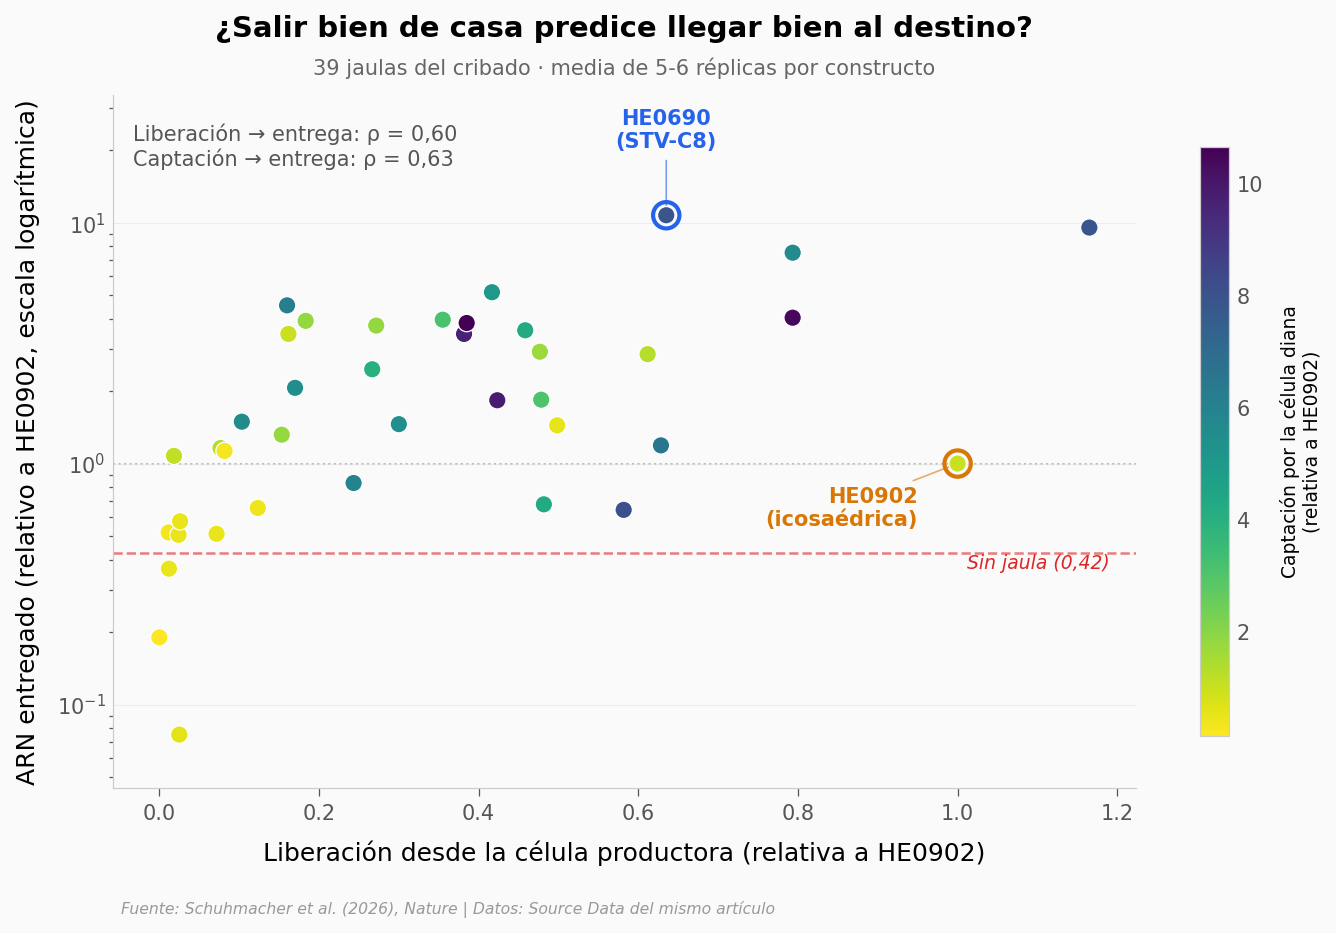

Liberación → entrega: rho de Spearman = 0,60, p = 5,9e-05, n = 39 (Shapiro p = 0,0046 → no normal, por eso Spearman)
Captación → entrega: rho de Spearman = 0,63, p = 2,0e-05, n = 39 (Shapiro p = 0,0007 → no normal, por eso Spearman)


In [4]:
fig, ax = plt.subplots(figsize=(11, 6))

sc = ax.scatter(jaulas.liberacion, jaulas.entrega, c=jaulas.captacion,
                cmap='viridis_r', s=70, edgecolors='white', linewidths=0.6,
                zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('Captación por la célula diana\n(relativa a HE0902)', fontsize=9)

ax.axhline(1.0, color=COLOR_CONTEXTO, linewidth=1, linestyle=':', zorder=1)
ax.axhline(cribado.entrega[CONTROL], color=COLOR_ALERTA, linewidth=1.2,
           linestyle='--', alpha=0.6, zorder=1)
ax.text(1.19, cribado.entrega[CONTROL] * 0.86,
        f'Sin jaula ({es(cribado.entrega[CONTROL])})', fontsize=9,
        color=COLOR_ALERTA, ha='right', style='italic')

ax.set_yscale('log')
ax.set_ylim(0.045, 34)

for nombre, texto, dx, dy, alin, color in [
        (GANADOR, 'STV-C8', 0.0, 1.9, 'center', COLOR_DATOS),
        (CAPSIDE, 'icosaédrica', -0.05, 0.55, 'right', COLOR_REFERENCIA)]:
    fila = jaulas.loc[nombre]
    ax.scatter([fila.liberacion], [fila.entrega], s=160, facecolors='none',
               edgecolors=color, linewidths=2, zorder=6)
    ax.annotate(f'{nombre}\n({texto})',
                xy=(fila.liberacion, fila.entrega),
                xytext=(fila.liberacion + dx, fila.entrega * dy),
                fontsize=10, fontweight='bold', color=color, ha=alin,
                arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.6))

rho_lib, p_lib = stats.spearmanr(jaulas.liberacion, jaulas.entrega)
rho_cap, p_cap = stats.spearmanr(jaulas.captacion, jaulas.entrega)
ax.text(0.02, 0.96, f'Liberación → entrega: ρ = {es(rho_lib)}\n'
                    f'Captación → entrega: ρ = {es(rho_cap)}',
        transform=ax.transAxes, fontsize=10, color='#555555', va='top')

ax.set_xlabel('Liberación desde la célula productora (relativa a HE0902)')
ax.set_ylabel('ARN entregado (relativo a HE0902, escala logarítmica)')
ax.set_title('¿Salir bien de casa predice llegar bien al destino?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '39 jaulas del cribado · media de 5-6 réplicas por constructo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cribado_pasos.png', dpi=200, bbox_inches='tight')
plt.show()

for etiqueta, serie in [('Liberación', jaulas.liberacion), ('Captación', jaulas.captacion)]:
    rho, p = stats.spearmanr(serie, jaulas.entrega)
    sh = stats.shapiro(serie).pvalue
    p_es = ('%.1e' % p).replace('.', ',')
    print(f'{etiqueta} → entrega: rho de Spearman = {es(rho)}, p = {p_es}, '
          f'n = {len(serie)} (Shapiro p = {es(sh, 4)} → no normal, por eso Spearman)')

### La cadena existe, pero es floja

Las dos correlaciones son **moderadas** (ρ alrededor de 0,60 sobre 39 jaulas). Salir bien de la célula productora ayuda a entregar más, pero explica una fracción del resultado: hay jaulas que se liberan poco y entregan mucho, y al revés. Optimizar un solo paso no basta.

El caso que mejor lo muestra es el propio andamio icosaédrico. En liberación es el **segundo mejor de 39**. En entrega cae al **puesto 28**. La forma a la que convergió media virología es excelente saliendo de casa y mediocre haciendo el trabajo — al menos con estos dominios colgados y en este ensayo.

## ¿Qué tan rara es la ganadora?

Con 39 jaulas ya hay una distribución. Veamos dónde cae cada una.

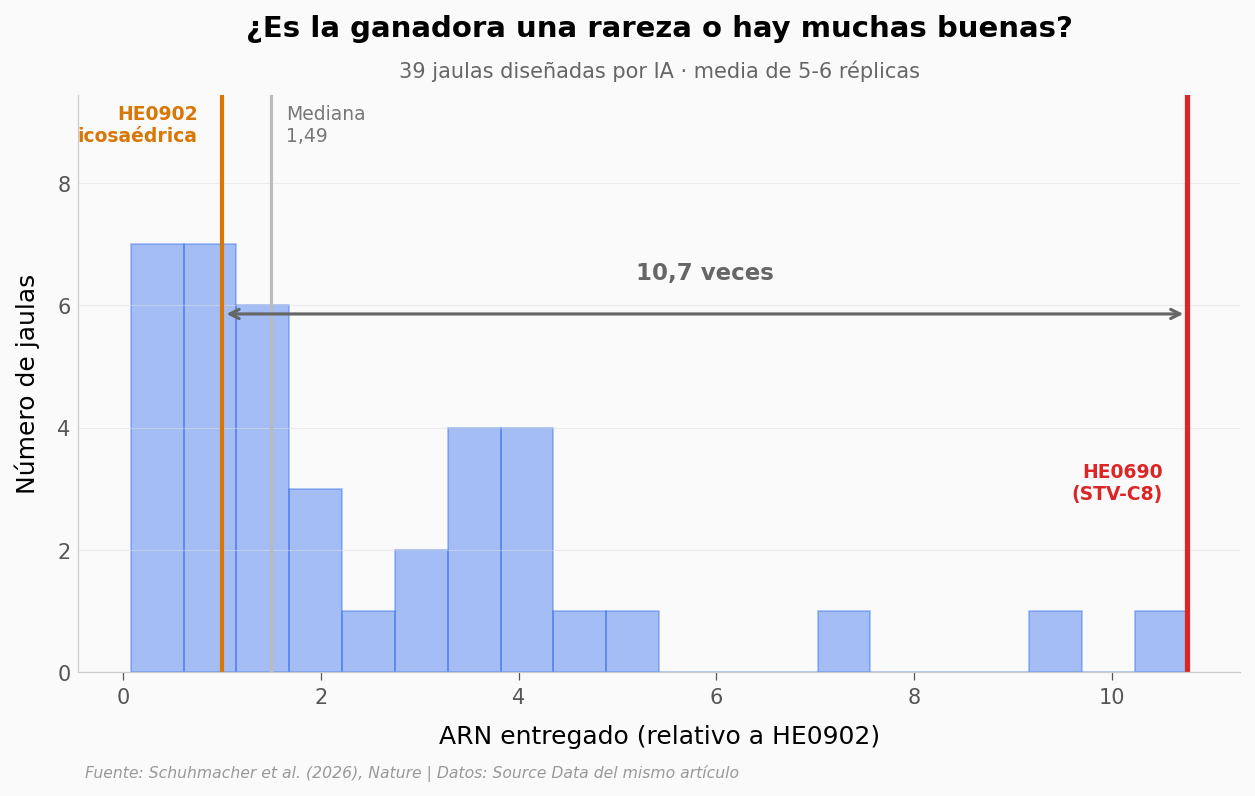

HE0690: puesto 1 de 39 · 10,77
HE0902: puesto 28 de 39 · 1,00
Jaulas que entregan más que la icosaédrica: 27 de 39
Jaulas que entregan más que no poner jaula: 36 de 39
HE0690 vs HE0902: razón 10,75 · d de Cohen = 15,1 · Mann-Whitney p = 0,0022 (n=6 vs 6)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

vals = jaulas.entrega.values
n, bins, patches = ax.hist(vals, bins=20, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.35
ax.set_ylim(0, y_max)

mediana = np.median(vals)
v_capside = jaulas.entrega[CAPSIDE]
v_ganador = jaulas.entrega[GANADOR]

ax.axvline(mediana, color=COLOR_CONTEXTO, linewidth=1.5)
ax.axvline(v_capside, color=COLOR_REFERENCIA, linewidth=2)
ax.axvline(v_ganador, color=COLOR_ALERTA, linewidth=2.5)

ax.annotate('', xy=(v_ganador, y_max * 0.62), xytext=(v_capside, y_max * 0.62),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((v_capside + v_ganador) / 2, y_max * 0.68,
        f'{es(v_ganador / v_capside, 1)} veces', ha='center', fontsize=11,
        fontweight='bold', color='#666666')

ax.text(mediana + 0.15, y_max * 0.92, f'Mediana\n{es(mediana)}', fontsize=9,
        color='#777777')
ax.text(v_capside - 0.25, y_max * 0.92, f'{CAPSIDE}\nicosaédrica', fontsize=9,
        color=COLOR_REFERENCIA, fontweight='bold', ha='right')
ax.text(v_ganador - 0.25, y_max * 0.30, f'{GANADOR}\n(STV-C8)', fontsize=9,
        color=COLOR_ALERTA, fontweight='bold', ha='right')

ax.set_xlabel('ARN entregado (relativo a HE0902)')
ax.set_ylabel('Número de jaulas')
ax.set_title('¿Es la ganadora una rareza o hay muchas buenas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '39 jaulas diseñadas por IA · media de 5-6 réplicas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_entrega.png', dpi=200, bbox_inches='tight')
plt.show()

rank_ganador = int(jaulas.entrega.rank(ascending=False)[GANADOR])
rank_capside = int(jaulas.entrega.rank(ascending=False)[CAPSIDE])
mejores = int((jaulas.entrega > v_capside).sum())
print(f'{GANADOR}: puesto {rank_ganador} de {len(jaulas)} · {es(v_ganador)}')
print(f'{CAPSIDE}: puesto {rank_capside} de {len(jaulas)} · {es(v_capside)}')
print(f'Jaulas que entregan más que la icosaédrica: {mejores} de {len(jaulas)}')
print(f'Jaulas que entregan más que no poner jaula: '
      f'{int((jaulas.entrega > cribado.entrega[CONTROL]).sum())} de {len(jaulas)}')

a = entrega[entrega.construct == GANADOR].senal
b = entrega[entrega.construct == CAPSIDE].senal
print(f'{GANADOR} vs {CAPSIDE}: razón {es(a.mean() / b.mean())} · '
      f'd de Cohen = {es(abs(d_de_cohen(a, b)), 1)} · '
      f'Mann-Whitney p = {es(stats.mannwhitneyu(a, b).pvalue, 4)} (n=6 vs 6)')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| STV-C8 necesita muchísimo menos ARN que una nanopartícula lipídica para la misma señal | ✅ | 12.991 veces menos (10,5 pg contra 136.673 pg por unidad de señal). d de Cohen = 24,0. **n=3 vs 3**: el p de Mann-Whitney da 0,1 porque ese es el mínimo posible con ese tamaño, no porque falte diferencia. La evidencia es la magnitud |
| La curva dosis-respuesta está desplazada más de mil veces | ✅ | 2.294 veces en la dosis que enciende la mitad de las células (0,76 pg contra 1.743 pg). n=3 por punto. Es el claim de la figura 2g del paper, distinto del anterior |
| La jaula ganadora entrega ~10,7 veces más ARN que el andamio icosaédrico | ✅ | Razón de medias 10,75 (10,77 contra 1,00). Mann-Whitney p = 0,002; d de Cohen = 15,1 con n=6 vs 6 |
| Poner una jaula de IA es mejor que no poner ninguna | ✅ | 36 de 39 jaulas superan al control `no cage` en entrega |
| La forma icosaédrica —la de casi todos los virus— no es la mejor aquí | ⚠️ | Queda 28ª de 39 en entrega y 2ª en liberación. Es un resultado **de este ensayo**, con estos dominios colgados: no dice que la cápside viral sea mala como virus |
| Salir bien de la célula productora predice entregar bien | ⚠️ | Solo en parte: ρ de Spearman = 0,60 (liberación) y 0,63 (captación) sobre 39 jaulas. Correlación moderada — hay jaulas que rompen el patrón en las dos direcciones |
| El paper construyó más de 100 vehículos | ⚠️ | El abstract habla de «más de 100», pero el cribado que graficamos aquí tiene **39 jaulas** más el control. El resto son variantes que no están en estos paneles |

> **Limitaciones.**
> - Todo lo que grafica este notebook es **cultivo celular** (HEK293T y células reporteras). No hay pacientes en ninguna de estas gráficas.
> - La comparación del titular y la curva dosis-respuesta van con **n=3**.
> - Las señales del cribado son **relativas a HE0902**, no eficiencias absolutas ni porcentajes de células.
> - Siete constructos quedan con 5 réplicas en vez de 6 en alguno de los tres paneles (cuatro en liberación, dos en captación, uno en entrega); se promedia lo que hay.
> - Los tres paneles del cribado traen los constructos en **orden distinto**; aquí se cruzan por nombre, nunca por posición.
> - El paper sí llega a un ratón, a células de un paciente con Duchenne y a un cerdo. Eso es **un** animal por experimento, y no está en estos datos.

## Ahora tú

En la carpeta `datos/` hay tres experimentos que no tocamos. Tres preguntas para abrirlos:

**1. ¿Cuánto pesa el gancho que agarra el ARN?**
`rnabp_liberacion_arn.csv` compara cuatro versiones del mismo vehículo cambiando solo el dominio que se pega al ARN (`noRBP`, `LS4`, `PCP`, `tdPCP`).
*Pista:* `pd.read_csv(f'{DATOS}/rnabp_liberacion_arn.csv').groupby('rna_binding_protein').arn_liberado_rel.agg(['mean','std'])`

**2. ¿Sobrevive el vehículo a la sangre?**
`estabilidad_sangre.csv` trae la entrega tras pretratar el STV-C8 con PBS, suero o sangre completa humana. Aquí lo interesante es una **ausencia** de diferencia: ¿la ves?
*Pista:* comparar las medias, y luego `stats.mannwhitneyu` entre `PBS` y `sangre completa`.

**3. ¿Sirve para algo más que encender luces?**
`reprogramacion_ascl1.csv` mide astrocitos de ratón convertidos con un ARN que enciende el gen ASCL1 — encender una luz es una cosa, reescribir lo que una célula es, otra. Compara los dos grupos y mira cuánto se sostiene la ventaja al cambiar de tarea.
*Pista:* `d_de_cohen()` ya está definida arriba; los grupos son de tamaño distinto (6 y 4).

Células encendidas (%) — media ± desviación
  EPN         1 µl: 3,3 ± 0,5 (n=4)
  EPN        10 µl: 48,5 ± 5,6 (n=4)
  SEND        1 µl: 1,4 ± 0,1 (n=4)
  SEND       10 µl: 1,9 ± 0,3 (n=4)
  STV-C8      1 µl: 91,3 ± 5,6 (n=4)
  STV-C8     10 µl: 97,6 ± 1,6 (n=4)
  Sin tratar  1 µl: 0,8 ± 0,4 (n=3)
  Sin tratar 10 µl: 0,8 ± 0,4 (n=3)
  VLP         1 µl: 2,4 ± 2,0 (n=4)
  VLP        10 µl: 13,5 ± 4,3 (n=4)



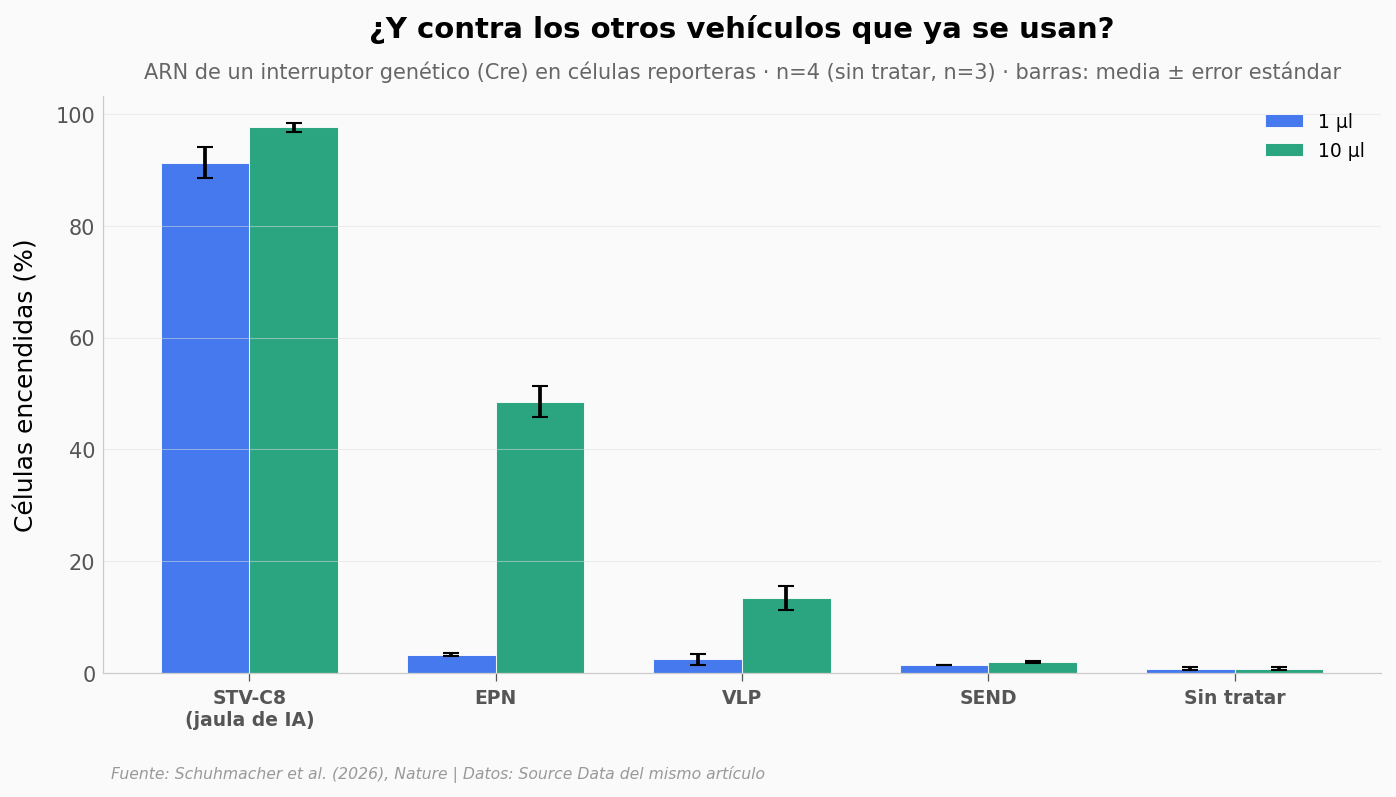

Con 1 µl: STV 91,3 % contra EPN 3,3 % — d de Cohen = 22,2 (n=4 vs 4)
Con 10 µl la distancia se acorta: EPN y VLP alcanzan a subir (48,6 % y 13,5 %); SEND se queda en 1,9 %, casi el nivel del sin tratar.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# El paper no solo comparó contra la nanopartícula lipídica: puso a STV-C8 contra
# otros tres vehículos de transferencia de ARN que ya se usan en laboratorio
# (EPN, VLP y SEND), a dos volúmenes distintos. ¿La ventaja aguanta?

resumen = (benchmark
           .groupby(['vehiculo', 'volumen_ul'])
           .pct_celulas_egfp_pos
           .agg(['mean', 'std', 'count']))
NOMBRES_ES = {'STV': 'STV-C8', 'Untreated': 'Sin tratar'}
print('Células encendidas (%) — media ± desviación')
for (veh, vol), fila in resumen.iterrows():
    print(f'  {NOMBRES_ES.get(veh, veh):<10} {vol:>2} µl: '
          f'{es(fila["mean"], 1)} ± {es(fila["std"], 1)} (n={int(fila["count"])})')
print()

fig, ax = plt.subplots(figsize=(11, 5))

orden = ['STV', 'EPN', 'VLP', 'SEND', 'Untreated']
nombres = ['STV-C8\n(jaula de IA)', 'EPN', 'VLP', 'SEND', 'Sin tratar']
ancho = 0.36
x = np.arange(len(orden))

for i, (vol, color, etiqueta) in enumerate([(1, COLOR_DATOS, '1 µl'),
                                            (10, COLOR_SECUNDARIO, '10 µl')]):
    sub = benchmark[benchmark.volumen_ul == vol]
    medias = [sub[sub.vehiculo == v].pct_celulas_egfp_pos.mean() for v in orden]
    sems = [sub[sub.vehiculo == v].pct_celulas_egfp_pos.sem() for v in orden]
    ax.bar(x + (i - 0.5) * ancho, medias, ancho, yerr=sems, capsize=4,
           color=color, alpha=0.85, label=etiqueta, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=9, fontweight='bold')
ax.set_ylabel('Células encendidas (%)')
ax.set_title('¿Y contra los otros vehículos que ya se usan?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'ARN de un interruptor genético (Cre) en células reporteras · '
                   'n=4 (sin tratar, n=3) · barras: media ± error estándar',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/benchmark_vehiculos.png', dpi=200, bbox_inches='tight')
plt.show()

uno = benchmark[benchmark.volumen_ul == 1]
stv = uno[uno.vehiculo == 'STV'].pct_celulas_egfp_pos
epn = uno[uno.vehiculo == 'EPN'].pct_celulas_egfp_pos
print(f'Con 1 µl: STV {es(stv.mean(), 1)} % contra EPN {es(epn.mean(), 1)} % '
      f'— d de Cohen = {es(abs(d_de_cohen(stv, epn)), 1)} (n=4 vs 4)')
print('Con 10 µl la distancia se acorta: EPN y VLP alcanzan a subir (48,6 % y 13,5 %); '
      'SEND se queda en 1,9 %, casi el nivel del sin tratar.')

---

## Fuentes

**Paper**: [Creating bottom-up RNA transfer vehicles from synthetic protein assemblies](https://doi.org/10.1038/s41586-026-10952-3)  
*Nature, 2026-09-02 · acceso abierto*

**Dataset canónico**: [Source Data Figs. 1–3 and Extended Data Figs. 1, 2 and 4–10](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-10952-3/MediaObjects/41586_2026_10952_MOESM4_ESM.xlsx)  
*Source Data del propio artículo — los nueve CSV de `datos/` salen de ahí.*

**Referencias citadas**: [Supplementary Information del mismo DOI](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-10952-3/MediaObjects/41586_2026_10952_MOESM1_ESM.pdf) — consultada para verificar qué NO contiene la Supplementary Table 1.

*17 afirmaciones del notebook verificadas contra estas fuentes*

---

**Licencia de los datos:** el Source Data de Nature acompaña un artículo de acceso abierto (CC BY 4.0).
**Código de este notebook:** [https://github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — reproducible de punta a punta.
**Canal:** Ciencia a Mordiscos · [cienciaamordiscos.com](https://cienciaamordiscos.com)